# Variance and Covariance — Hands-on Tutorial

In this notebook we'll build intuition for:
1. What variance *looks like* — and when noise drowns out a signal
2. How covariance captures relationships between variables
3. Why summary statistics alone can be misleading (Anscombe's quartet)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

---
## Part 1: Signal vs Noise

We'll generate a sine wave and add Gaussian noise on top of it.
Use the sliders to adjust:
- **Amplitude** — how strong the signal is
- **Noise std** — how spread out (noisy) the random values are

**Question:** At what combination of amplitude and noise can you no longer see the signal?

In [2]:
# x-axis: 500 evenly spaced points from 0 to 4*pi
x = np.linspace(0, 4 * np.pi, 1000)

def plot_signal_and_noise(amplitude, noise_std):
    """Plot a sine wave with added Gaussian noise."""

    # The clean signal
    signal = amplitude * np.sin(x)

    # Random noise drawn from a normal distribution
    noise = np.random.normal(scale=noise_std, size=len(x))

    # What we "observe" is signal + noise
    observed = signal + noise

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, observed, s=4, label='Observed (signal + noise)')
    ax.plot(x, signal, color='red', linewidth=2, label=f'Signal (amplitude={amplitude:.1f})', alpha=0.1)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.3)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_ylim(-15, 15)
    ax.set_title(f'Amplitude = {amplitude:.1f},  Noise σ = {noise_std:.1f}')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

interact(
    plot_signal_and_noise,
    amplitude=FloatSlider(value=3.0, min=0.0, max=10.0, step=0.1, description='Amplitude'),
    noise_std=FloatSlider(value=1.0, min=0.0, max=10.0, step=0.1, description='Noise σ'),
);

interactive(children=(FloatSlider(value=3.0, description='Amplitude', max=10.0), FloatSlider(value=1.0, descri…

### Think about it

- What happens when `noise_std` is much larger than `amplitude`?
- What is the *ratio* of amplitude to noise when the signal just barely disappears?
  (This ratio is related to **signal-to-noise ratio**, or SNR.)

---
## Part 2: Covariance by Construction

Covariance measures how two variables move together:

$$\text{Cov}(X, Y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

- **Positive covariance**: when X goes up, Y tends to go up
- **Negative covariance**: when X goes up, Y tends to go down
- **Zero covariance**: X and Y don't move together

Let's construct all three cases and see what the covariance matrix looks like.

In [3]:
np.random.seed(42)  # for reproducibility
n = 300

# (a) Independent — no relationship
x_ind = np.random.normal(size=n)
y_ind = np.random.normal(size=n)

# (b) Positively correlated — Y increases with X
x_pos = np.random.normal(size=n)
y_pos = 0.8 * x_pos + 0.3 * np.random.normal(size=n)

# (c) Negatively correlated — Y decreases as X increases
x_neg = np.random.normal(size=n)
y_neg = -0.8 * x_neg + 0.3 * np.random.normal(size=n)

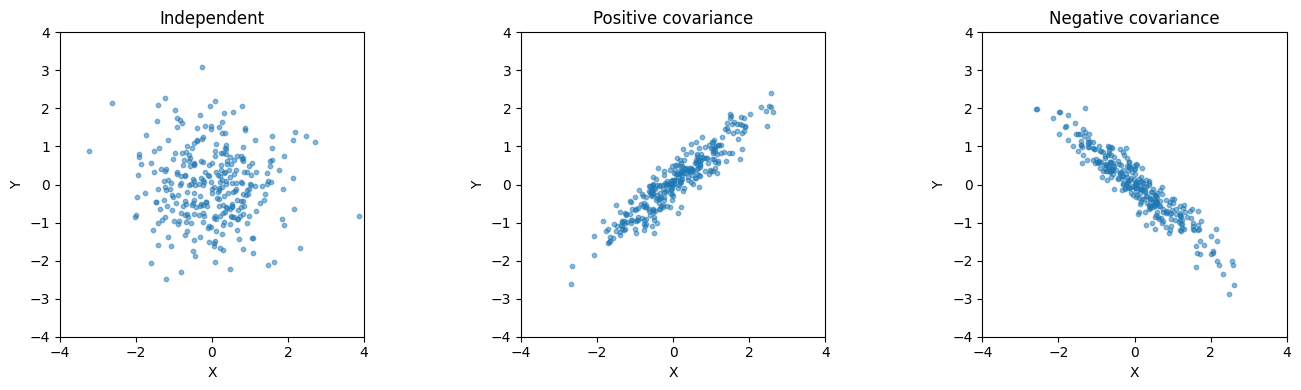

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    (x_ind, y_ind, 'Independent'),
    (x_pos, y_pos, 'Positive covariance'),
    (x_neg, y_neg, 'Negative covariance'),
]

for ax, (xd, yd, title) in zip(axes, datasets):
    ax.scatter(xd, yd, s=10, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Now let's compute the covariance matrix for each case.

The covariance matrix for two variables X, Y is:

$$C = \begin{bmatrix} \text{Var}(X) & \text{Cov}(X,Y) \\ \text{Cov}(Y,X) & \text{Var}(Y) \end{bmatrix}$$

- The **diagonal** entries are the variances of each variable
- The **off-diagonal** entries are the covariances between variables

In [5]:
for xd, yd, label in datasets:
    cov_matrix = np.cov(xd, yd)
    print(f"{label}:")
    print(f"  Cov matrix:\n  {cov_matrix}")
    print(f"  Cov(X,Y) = {cov_matrix[0, 1]:.3f}")
    print()

Independent:
  Cov matrix:
  [[ 0.96863722 -0.03833446]
 [-0.03833446  0.92470889]]
  Cov(X,Y) = -0.038

Positive covariance:
  Cov matrix:
  [[0.99336398 0.79192934]
 [0.79192934 0.7231091 ]]
  Cov(X,Y) = 0.792

Negative covariance:
  Cov matrix:
  [[ 0.99604127 -0.81605745]
 [-0.81605745  0.75545875]]
  Cov(X,Y) = -0.816



### Exercise

Try changing the coefficient in `y_pos = 0.8 * x_pos + ...` to different values.

- What happens to the covariance when you change `0.8` to `0.2`? To `2.0`?
- What happens to the scatter plot shape?

---
## Part 3: Anscombe's Quartet

Four datasets that have nearly identical summary statistics
(mean, variance, correlation, linear fit) — but look completely different.

This is a famous example of why you should **always plot your data**.

In [6]:
# Anscombe's quartet — the four datasets
anscombe = {
    'I':   {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]},
    'II':  {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]},
    'III': {'x': [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5],
            'y': [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]},
    'IV':  {'x': [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8],
            'y': [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]},
}

In [7]:
# Print the summary statistics for each dataset
print(f"{'Dataset':<10} {'Mean X':>8} {'Mean Y':>8} {'Var X':>8} {'Var Y':>8} {'Cov(X,Y)':>10}")
print('-' * 54)

for name, data in anscombe.items():
    x = np.array(data['x'])
    y = np.array(data['y'])
    print(f"{name:<10} {x.mean():>8.2f} {y.mean():>8.2f} {x.var():>8.2f} {y.var():>8.2f} {np.cov(x, y)[0,1]:>10.2f}")

Dataset      Mean X   Mean Y    Var X    Var Y   Cov(X,Y)
------------------------------------------------------
I              9.00     7.50    10.00     3.75       5.50
II             9.00     7.50    10.00     3.75       5.50
III            9.00     7.50    10.00     3.75       5.50
IV             9.00     7.50    10.00     3.75       5.50


The statistics are nearly identical! Now let's plot them:

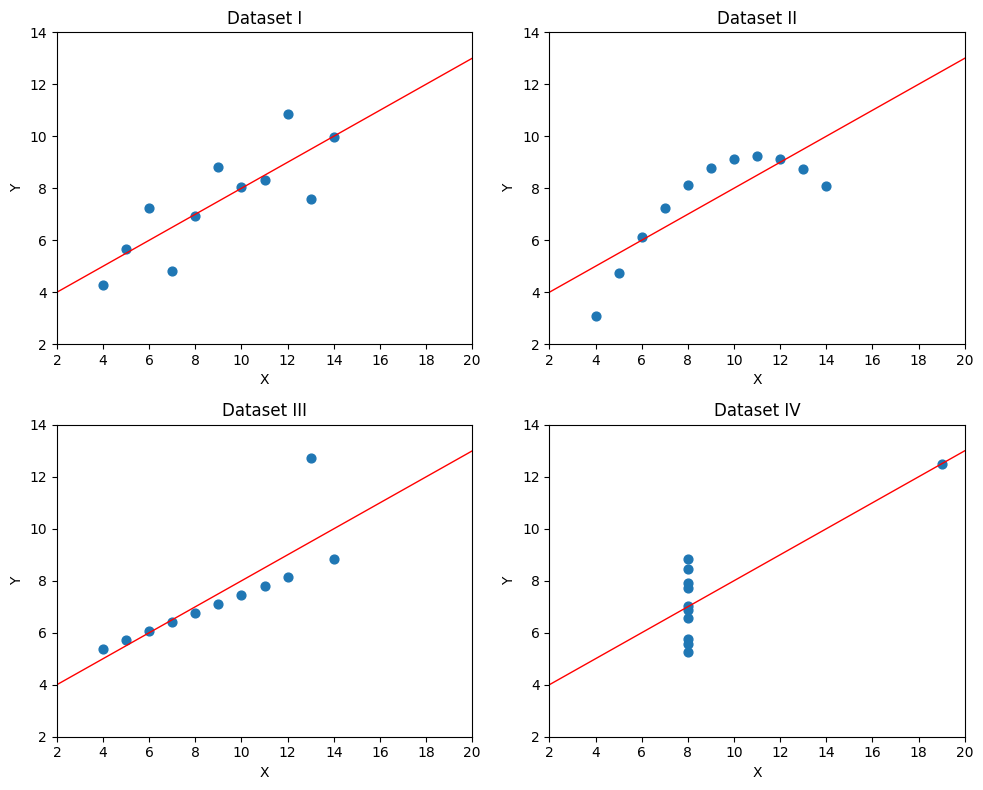

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, data) in zip(axes.flat, anscombe.items()):
    x = np.array(data['x'])
    y = np.array(data['y'])

    # Scatter plot
    ax.scatter(x, y, s=40)

    # Fit and plot a line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(2, 20, 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1)

    ax.set_title(f'Dataset {name}')
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

### Think about it

- Which dataset has an outlier pulling the fit?
- Which dataset is clearly non-linear despite having the same correlation coefficient?
- What would happen if you computed variance and covariance on dataset IV without looking at the plot first?